In [1]:
import numpy as np
import pandas as pd

# Matplotlib settings
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.gridspec import GridSpec
%matplotlib notebook

plt.style.use('seaborn-deep')


/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_49907/1349987015.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


### Load data

In [4]:
import json
carbon_keys = ['C1', 'C30', 'C17', 'C46', 'C47']

with open("data_fig2_tau_sweep.json") as file:
    tau_sweep = json.load(file)
    
with open("data_fig2_freq_sweep.json") as file:
    freq_sweep = json.load(file)
    
with open("data_fig2_spin_params.json") as file:
    spin_params = json.load(file)

### Make Plot

In [5]:
plt.style.use('ggplot')
plt.style.use('seaborn-pastel')
plt.style.use('seaborn-whitegrid')
plt.style.use('tableau-colorblind10')
plt.style.use('seaborn-deep')

plt.rcParams.update({'font.size': 7,
                     'font.family':r'Arial',
                     'font.style':'normal',
                     'axes.grid' : False,
                     'ytick.color': '1.',
                     'lines.linewidth':1,
                     'axes.labelsize':'medium'

                    })

axes_color =  '0.8'

plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['ytick.major.width'] = 0.8
plt.rcParams['ytick.color'] = '.15'

plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['xtick.major.width'] = 0.8
plt.rcParams['xtick.color'] = '.15'

markersize = 6


/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_49907/808368384.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-pastel')
/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_49907/808368384.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_49907/808368384.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the s

<IPython.core.display.Javascript object>


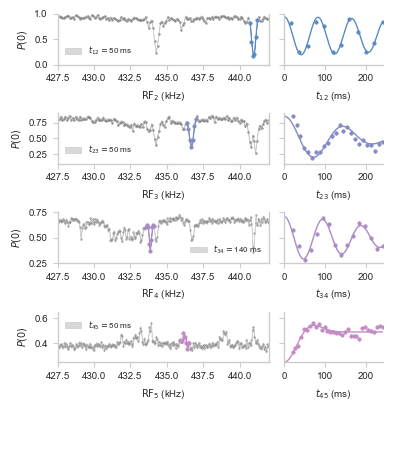

In [6]:
fig = plt.figure(figsize = [10/2.54,12/2.54])

gs = GridSpec(len(carbon_keys), 3, figure=fig)


color_hex_list = ['#588bc5', '#838bc5', '#aa8bc5', '#c38bc5' ]

coupling_color = '#65C8D0'
coupling_color = '#fcd0a1'

y_lim_list = [[0, 1.], [0.1, 0.9], [0.25, 0.75], [0.25,0.65]]
alpha_list = [0.7, 0.7, 0.45, 0.45]

carbon_highlight_list = []

ax_dict = {}
for i, carbon_key in enumerate(carbon_keys[0:-1]):
    ax_dict[carbon_key + '_freq'] = fig.add_subplot(gs[i,:2])
    ax_dict[carbon_key + '_tau'] = fig.add_subplot(gs[i,2])
    ax_dict[carbon_key + '_tau_value'] = freq_sweep[carbon_key]['tau_value']
    ax_dict[carbon_key + '_ylim'] = y_lim_list[i]
    ax_dict[carbon_key + '_highlight'] = carbon_keys[i+1]
    ax_dict[carbon_key + '_color_hex'] = color_hex_list[i]


delta_f = 0.65 # kHz
data_color =  'grey'
sim_color  =  'darkgrey'




for i,carbon_key in enumerate(carbon_keys[0:-1]):
    
    ###################################
    ### SEDOR part (note: t = 2*tau) ###
    ####################################
    
    color = ax_dict[carbon_key + '_color_hex']
    plot_ax = ax_dict[carbon_key+'_tau']

    x_vals     = 2*np.array(tau_sweep[carbon_key]['x_vals'])
    y_vals     = np.array(tau_sweep[carbon_key]['y_vals'])
    y_err_vals = np.array(tau_sweep[carbon_key]['y_err_vals'])
    x_vals_fit = 2*np.array(tau_sweep[carbon_key]['x_fit'])
    y_vals_fit = np.array(tau_sweep[carbon_key]['y_fit'])

    plot_ax.scatter(x_vals, y_vals, marker = 'o', color = color, s= markersize)
    plot_ax.errorbar(x_vals, y_vals, y_err_vals,fmt = ' ', color = color, alpha = 0.5)
    plot_ax.plot(x_vals_fit, y_vals_fit, color = color)


    # Axes settings
    y_min = y_lim_list[i][0] 
    y_max = y_lim_list[i][1]
    plot_ax.set_xlim([0,2*120])
    plot_ax.set_yticklabels([])
    plot_ax.set_ylim([y_min, y_max])
    plot_ax.spines['top'].set_visible(False)
    plot_ax.spines['right'].set_visible(False)
    xlabel = r'$t_{'+str(i+1)+str(i+2)+'}$ (ms)'
    plot_ax.set_xlabel(xlabel)
    plot_ax.tick_params(color = axes_color )


    
    #########################
    ### Spectroscopy part ###
    #########################

    tau_value = ax_dict[carbon_key + '_tau_value']
    plot_ax = ax_dict[carbon_key+'_freq']
    label = r'$t_{'+str(i+1)+str(i+2)+'} = $'+str(2*tau_value)+' ms'#.format(str(12))
    
    x_vals     = np.array(freq_sweep[carbon_key]['x_vals'])
    y_vals     = np.array(freq_sweep[carbon_key]['y_vals'])
    y_err_vals = np.array(freq_sweep[carbon_key]['y_err_vals'])
    
    plot_ax.scatter(x_vals,y_vals, marker = '.', color = data_color, s = markersize, alpha = alpha_list[i])
    plot_ax.fill_between(x_vals,y_vals-y_err_vals,y_vals+y_err_vals, color = data_color, alpha = 0.3, label = label)

    ### Recoloring around the resonance: 
    carbon_key_2 = ax_dict[carbon_key + '_highlight']
    f_res = np.sqrt( (432 - spin_params[carbon_key_2]['par']*1e-3)**2 + (spin_params[carbon_key_2]['perp']*1e-3)**2 )
    f_res = (432 - spin_params[carbon_key_2]['par']*1e-3)

    # experiment
    index_start = 0
    index_stop  = 0
    for k in range(len(x_vals)):
        if x_vals[k]<f_res - delta_f/2:
            index_start +=1
        if x_vals[k]<f_res + delta_f/2:
            index_stop +=1
    plot_ax.scatter(x_vals[index_start:index_stop],y_vals[index_start:index_stop], marker = 'o', color = color, s = markersize)
    plot_ax.fill_between(x_vals[index_start:index_stop],y_vals[index_start:index_stop]-y_err_vals[index_start:index_stop],y_vals[index_start:index_stop]+y_err_vals[index_start:index_stop], color = color, alpha = 1)
    
    # Axes settings
    plot_ax.set_xlim([427.5,442])
    plot_ax.set_ylabel('$P(0)$')
    plot_ax.set_ylim(ax_dict[carbon_key + '_ylim'])
    xlabel = r'$\mathrm{RF}_{'+str(i+2)+'}$ (kHz)'#.format(str(12))
    plot_ax.set_xlabel(xlabel )
    plot_ax.spines['top'].set_visible(False)
    plot_ax.tick_params(color = axes_color )
    plot_ax.set_ylim([y_min, y_max])
    plot_ax.legend(fontsize = 'small')

plt.tight_layout()
plt.show()

### Save figure 

In [5]:
plt.savefig('figure_2.pdf', bbox_inches='tight')